# ANN Lab 10-2

**Name:** Muhammad Taqui  
**Enrollment:** 01-136221-021  
**Date:** November 21, 2024

**Aim:** Compare the Adam, RMSprop, and Momentum optimizers on the MNIST digit classification task.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Input
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0, 1] and flatten to a 784-length vector per image
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
def create_model(optimizer):
    model = models.Sequential()
    model.add(Input(shape=(28 * 28,)))  # explicit Input layer, avoids the input_shape deprecation warning
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(10, activation='softmax'))  # output layer, 10 digit classes
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [3]:
optimizers = {
    'Adam': Adam(),
    'RMSprop': RMSprop(),
    'Momentum': SGD(momentum=0.9)
}

results = {}

for name, optimizer in optimizers.items():
    print(f"\nTraining with {name} optimizer")
    model = create_model(optimizer)
    history = model.fit(
        x_train, y_train,
        epochs=7,
        batch_size=64,
        validation_data=(x_test, y_test),
        verbose=2
    )
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
    results[name] = {
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'history': history.history
    }



Training with Adam optimizer
Epoch 1/7
938/938 - 8s - 8ms/step - accuracy: 0.9032 - loss: 0.3357 - val_accuracy: 0.9521 - val_loss: 0.1637
Epoch 2/7
938/938 - 3s - 3ms/step - accuracy: 0.9520 - loss: 0.1641 - val_accuracy: 0.9649 - val_loss: 0.1190
Epoch 3/7
938/938 - 3s - 3ms/step - accuracy: 0.9635 - loss: 0.1226 - val_accuracy: 0.9708 - val_loss: 0.0969
Epoch 4/7
938/938 - 3s - 3ms/step - accuracy: 0.9703 - loss: 0.0990 - val_accuracy: 0.9718 - val_loss: 0.0921
Epoch 5/7
938/938 - 4s - 4ms/step - accuracy: 0.9743 - loss: 0.0843 - val_accuracy: 0.9763 - val_loss: 0.0781
Epoch 6/7
938/938 - 3s - 3ms/step - accuracy: 0.9776 - loss: 0.0736 - val_accuracy: 0.9773 - val_loss: 0.0780
Epoch 7/7
938/938 - 5s - 5ms/step - accuracy: 0.9795 - loss: 0.0655 - val_accuracy: 0.9795 - val_loss: 0.0720

Training with RMSprop optimizer
Epoch 1/7
938/938 - 6s - 6ms/step - accuracy: 0.9051 - loss: 0.3273 - val_accuracy: 0.9531 - val_loss: 0.1602
Epoch 2/7
938/938 - 3s - 3ms/step - accuracy: 0.9524 - lo

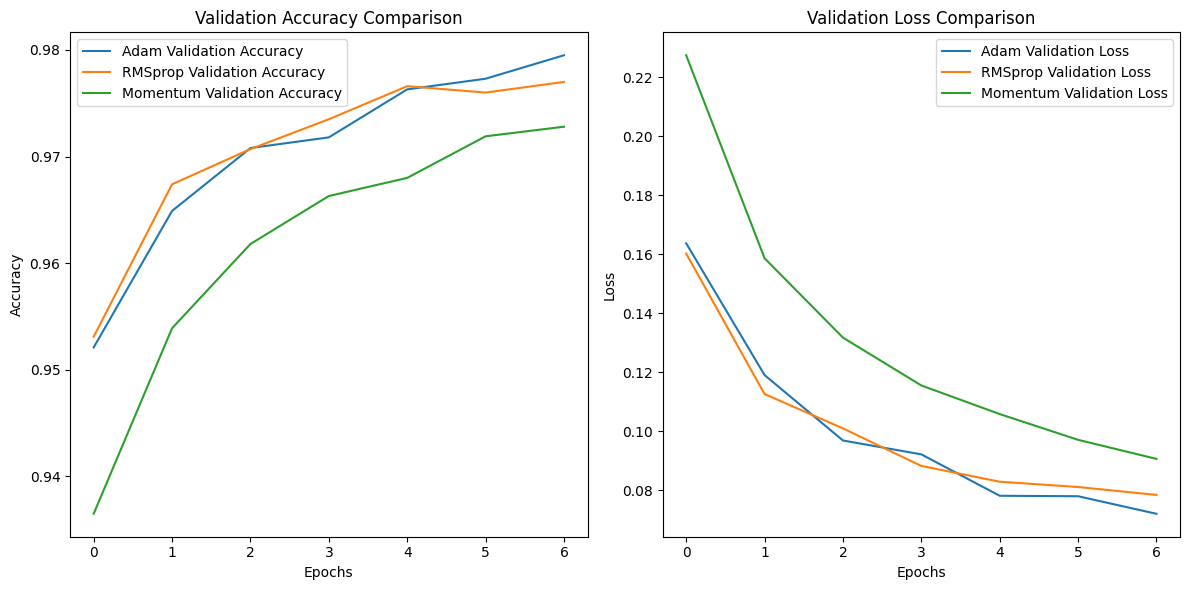

Adam - Test Accuracy: 0.9795, Test Loss: 0.0720
RMSprop - Test Accuracy: 0.9770, Test Loss: 0.0784
Momentum - Test Accuracy: 0.9728, Test Loss: 0.0906


In [4]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for name in optimizers.keys():
    plt.plot(results[name]['history']['val_accuracy'], label=f'{name} Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
for name in optimizers.keys():
    plt.plot(results[name]['history']['val_loss'], label=f'{name} Validation Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

for name in optimizers.keys():
    print(f"{name} - Test Accuracy: {results[name]['test_accuracy']:.4f}, Test Loss: {results[name]['test_loss']:.4f}")


## Optimizer background

In neural network optimization, selecting the right algorithm for updating weights plays a critical role in achieving efficient and accurate training. Adam, RMSprop, and Momentum introduce distinct approaches to accelerate convergence and improve performance.

**Gradient descent overview:** Gradient descent updates weights in the opposite direction of the loss gradient to minimize it. Standard gradient descent can be slow and sensitive to the learning rate, which motivates the variants below.

### 1. Momentum

Momentum speeds up learning by accumulating past gradients into a moving average, smoothing out updates and accelerating convergence in directions where gradients are consistent.

- Introduces a moving average of gradients.
- Reduces oscillation and speeds up convergence in valleys.
- Controlled by a momentum coefficient $\beta$ (typically 0.9).

Update rule: $v_t = \beta v_{t-1} - \eta \nabla L(W_t)$, then $W_t = W_t + v_t$

### 2. RMSprop (Root Mean Square Propagation)

RMSprop adapts the learning rate for each parameter using a running average of squared gradients, which stabilizes updates for sparse features or noisy gradients.

- Adjusts the learning rate per parameter.
- Effective for non-stationary and noisy problems.
- Controlled by a decay rate $\beta$ (typically 0.9) and a small $\epsilon$ for numerical stability.

Update rule: $E[g^2]_t = \beta E[g^2]_{t-1} + (1-\beta) g_t^2$, then $W_t = W_t - \dfrac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \nabla L(W_t)$

### 3. Adam (Adaptive Moment Estimation)

Adam combines Momentum and RMSprop, using both the first moment (mean of gradients) and the second moment (variance of gradients) to adaptively adjust the learning rate for each parameter.

- Combines velocity and adaptivity.
- Controlled by $\beta_1$ (momentum term) and $\beta_2$ (scaling term), typically 0.9 and 0.999.

Update rule:
$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$,
$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$,
bias-corrected as $\hat{m}_t = \dfrac{m_t}{1-\beta_1^t}$, $\hat{v}_t = \dfrac{v_t}{1-\beta_2^t}$,
then $W_t = W_t - \dfrac{\eta}{\sqrt{\hat{v}_t} + \epsilon}\hat{m}_t$

### Comparison

| Aspect | Momentum | RMSprop | Adam |
|---|---|---|---|
| Adaptivity | No | Yes | Yes |
| Speed of convergence | Moderate | Fast | Fast |
| Memory requirements | Low | Moderate | Moderate |
| Best for sparse data | No | Yes | Yes |
| Ease of tuning | Moderate | Moderate | Easier |

### Conclusion

Momentum speeds up convergence by incorporating past gradients, RMSprop adapts learning rates per parameter, and Adam combines both, which is why it is widely used as a default optimizer in modern deep learning. The empirical comparison above, trained on MNIST for 7 epochs each, illustrates these convergence and stability differences directly.

// iTaqiZ - PK